### Kepler's Equations and Position Estimation

#### Using the Orbit object to convert position and velocity to keplerian elements

In [1]:
from math_tools import *
from graphing_utils import Graph
from orbit_package import Orbit

gr = Graph()
orb = Orbit()

# Values of r,v and mu to get elements for
mu = 4e5 # km^3/s^2
r0_vec = np.array([6e3,6e3,6e3]) # km
v0_vec = np.array([-5,5,0]) #km/s

# Finding kep elements
elements = orb.orbital_elements(r0_vec,v0_vec,mu)
orb.print_elements(elements)



SMA: 14825.777163600662
RAAN: 5.497787143782138
Arg Periapsis: 1.5707963267948966
Inclination: 0.6154797086703874
Orbit Period: 17933.954973952295
Mean Anomaly: 0.0
Eccentric Anomaly: 0.0
Mean Motion: 0.00035035134839501015
True Anomaly: 1.4901161193847656e-08
Orbit Type: prograde


### Creating an Ephemeris object for the orbit

In [2]:
dt = np.linspace(-2*7200,2*7200,2000)
eph = orb.create_propagated_ephemeris(r0_vec,v0_vec,mu,dt)

##### Using built in Ephemeris functions to extract r,c,t and elements 

In [3]:
all_r = eph.all_r()
all_v = eph.all_v()
all_t = eph.all_t()
all_ele = eph.all_ele()
print(all_t)

[datetime.datetime(2025, 9, 3, 15, 0, 50, 207324, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 1, 4, 614528, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 1, 19, 21731, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 1, 33, 428935, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 1, 47, 836138, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 2, 2, 243342, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 2, 16, 650546, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 2, 31, 57749, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 2, 45, 464953, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 2, 59, 872156, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 3, 14, 279360, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 3, 28, 686564, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 9, 3, 15, 3, 43, 93

#### Plotting the results of the ephemeris
##### Several functions exist within the graph object to graph different elements of the ephemeris object. These can be referenced as shown to visualize and understand the orbits better

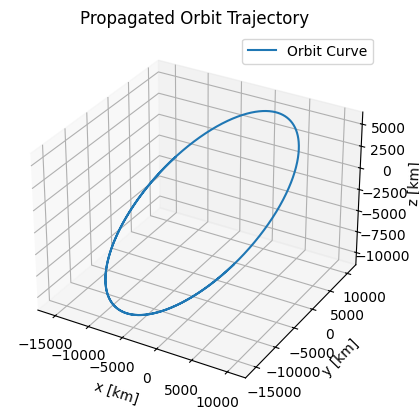

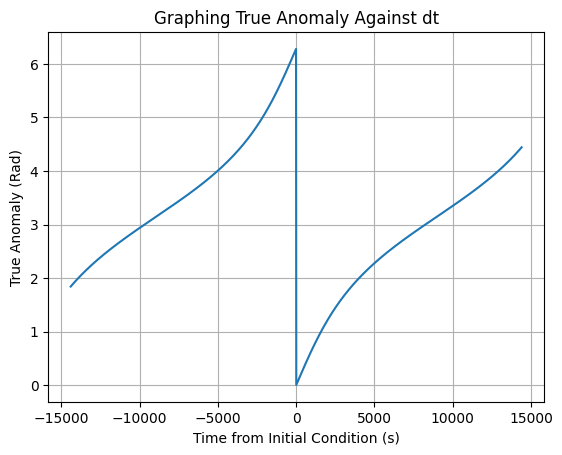

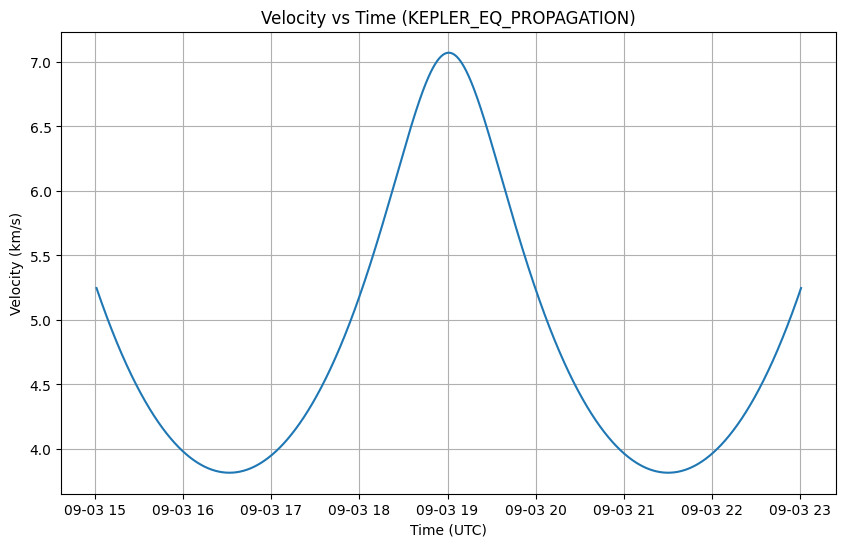

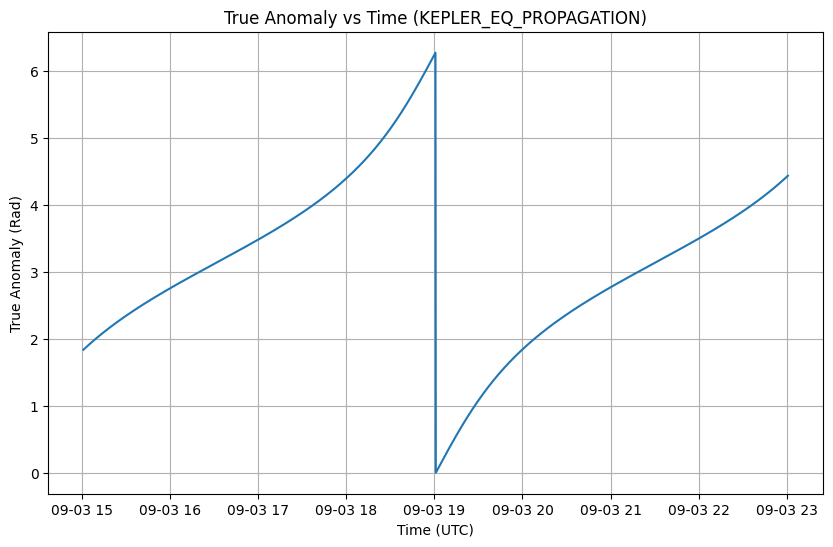

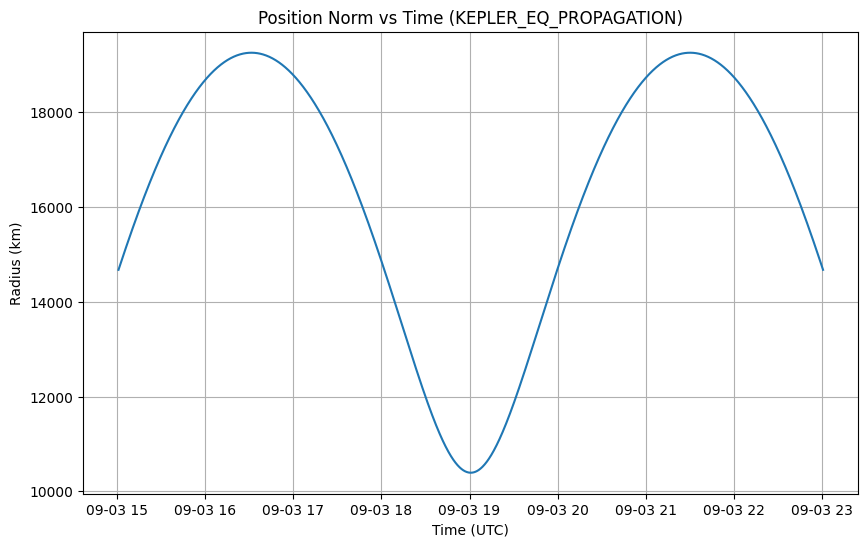

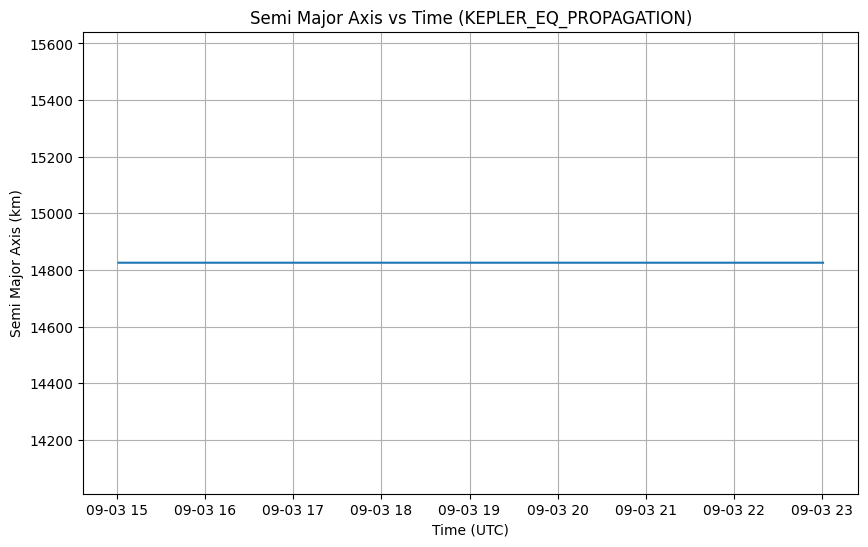

In [4]:
from graphing_utils import Graph

gr = Graph()
gr.plot_eph_pos_vector(eph,'line')
nu = eph.all_nu()
gr.plot_dt_simple(dt,nu,['True Anomaly','Rad'])
gr.plot_eph_v_norm(eph)
gr.plot_eph_nu(eph)
gr.plot_eph_r_norm(eph)
gr.plot_eph_sma(eph)